In [20]:
#These are the dataset given to us from kagglehub 
#https://www.kaggle.com/datasets/heptapod/titanic/data
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix

titanic = pd.read_csv("titanic.csv")

titanic.head()

,Passengerid,Age,Fare,Sex,sibsp,zero,zero.1,zero.2,zero.3,zero.4,...,zero.12,zero.13,zero.14,Pclass,zero.15,zero.16,Embarked,zero.17,zero.18,2urvived
0,1,22.0,7.2500,0,1,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
1,2,38.0,71.2833,1,1,0,0,0,0,0,...,0,0,0,1,0,0,0.0,0,0,1
2,3,26.0,7.9250,1,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,1
3,4,35.0,53.1000,1,1,0,0,0,0,0,...,0,0,0,1,0,0,2.0,0,0,1
4,5,35.0,8.0500,0,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0


In [8]:
#let me clean this up a little before moving on

#This removes the zero columns
titanic = titanic.loc[:, ~titanic.columns.str.startswith("zero")]

#Before moving on, let's identify what the non-obvious category represents

#sibsp = number of siblings and spouses
#Parch = number of parents and children
#Pclass = 1st class, 2nd class, 3rd class

In [9]:
#Time to move on to Decision Trees

#Remove any unnecessary variables that won't affect the outcome
titanic = titanic.drop(columns=["Passengerid"])

#Here are our x and y variables
x = titanic[["Age", "Fare", "Sex", "sibsp", "Parch", "Pclass", "Embarked"]]
y = titanic["2urvived"]

In [15]:
#Split the data to use for training and testing
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

#test_size = puts 20% of data for testing, the rest for training
#random_state controls the randomness, 42 is just a commonly used number for here

In [16]:
#Create the Decision Tree
model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

#max_depth limits the tree to 4 levels, more = more complicated

#Model of the training data
model.fit(x_train, y_train)

#Making a model of the predicted (test) data
y_pred = model.predict(X_test)

In [17]:
#Checking out the accuracy of our data
print("Accuracy:", accuracy_score(y_test, y_pred))

#Confusion Matrix of our data
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.7748091603053435
[[172  17]
 [ 42  31]]


In [22]:
#Based on the results above

#Accuracy of our model is 77.4%
#172 correctly predicted they did not survive (TP)
#17 predicted survived, but didn't (FP)
#42 predicted didn't survived, but did (FN)
#31 correctly predicted they survived (TN)

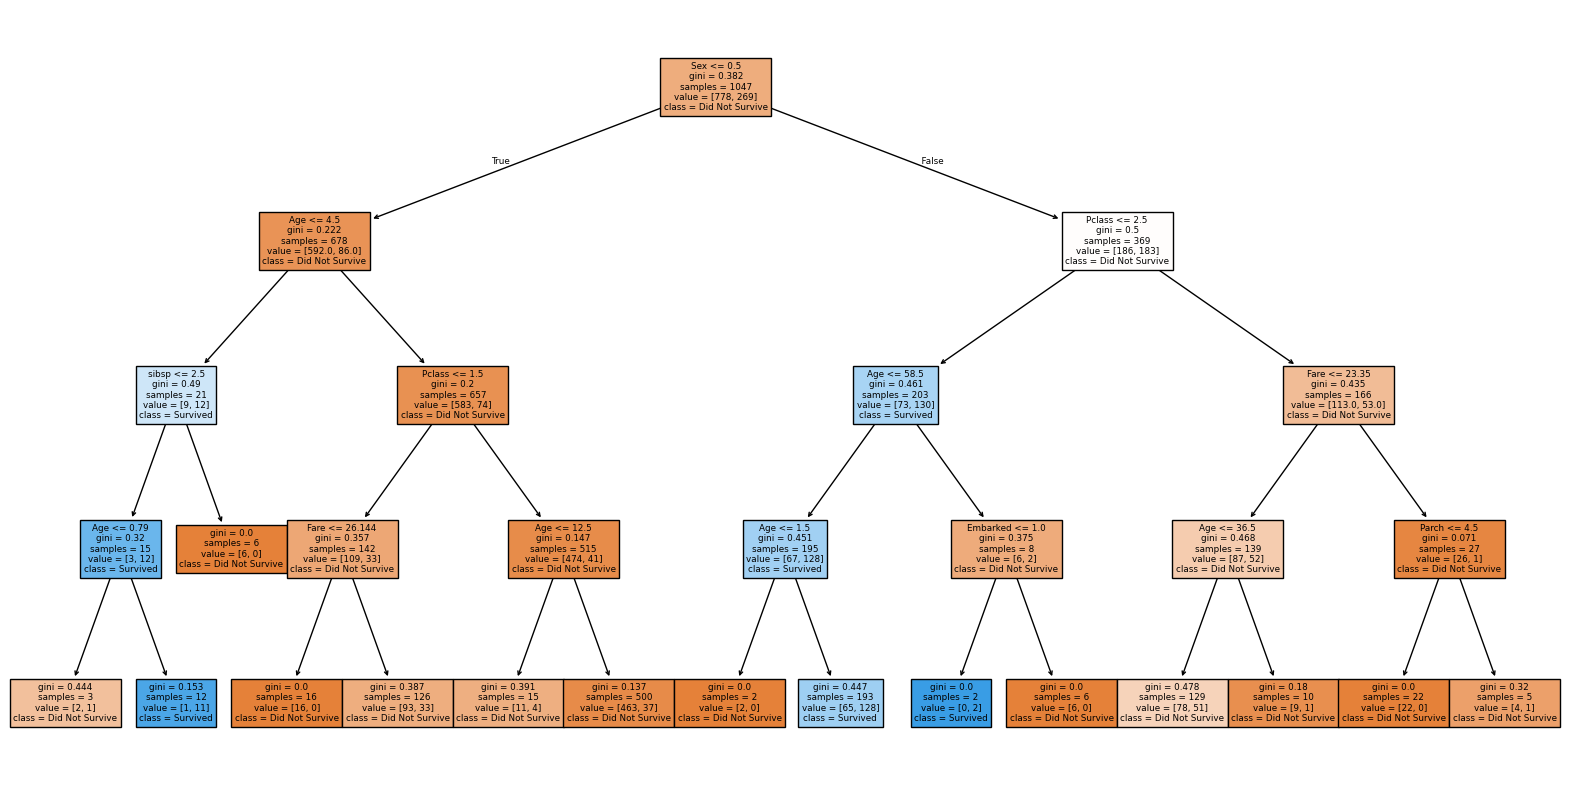

In [19]:
#What the decision tree looks like
plt.figure(figsize=(20, 10))

plot_tree(
    model,
    feature_names=x.columns,
    class_names=["Did Not Survive", "Survived"],
    filled=True
)

plt.show()

In [23]:
#Recap: We use decision trees to predict the outcome (yes/no) for a series of if/then decisions